In [1]:
from sklearn.model_selection import train_test_split
from analysis_utils import *

# Görselleştirme Ayarları
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/student_dataset_10000_rows.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

1. Veri Yüklendi. Boyut: (10000, 8)


In [3]:
# --- 2. Numerical Columns Statistical Summary ---
print("\n--- 2. İstatistiksel Özet ---")
display(df.describe().T[["mean", "std", "min", "max"]])


--- 2. İstatistiksel Özet ---


,mean,std,min,max
study_hours,5.989600,3.163589,1.00,11.0
attendance,69.884600,17.616530,40.00,100.0
sleep_hours,6.498500,1.709354,4.00,9.0
internet_usage,6.062600,3.138163,1.00,11.0
assignments_completed,9.988400,6.034145,0.00,20.0
previous_score,64.911000,17.503020,35.00,95.0
exam_score,86.704207,15.058383,26.67,100.0
placement_status,0.835600,0.370657,0.00,1.0


In [4]:
# --- 3. Check Missing Values ---
missing_counts = df.isnull().sum()
print("\n4. Eksik Değer Kontrolü:")
print(
    missing_counts[missing_counts > 0]
    if missing_counts.sum() > 0
    else "Eksik değer yok."
)


4. Eksik Değer Kontrolü:
Eksik değer yok.


In [5]:
# --- 4. Check Variable Distribution ---
print("\n5. Hedef Değişken Dağılımı:")
print(df["placement_status"].value_counts())


5. Hedef Değişken Dağılımı:
placement_status
1    8356
0    1644
Name: count, dtype: int64



6. Görselleştirme: Dağılım ve Aykırı Değer (Outlier) İncelemesi


/tmp/ipykernel_101012/3444806100.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["placement_status"], y=df["study_hours"], palette="Set2")


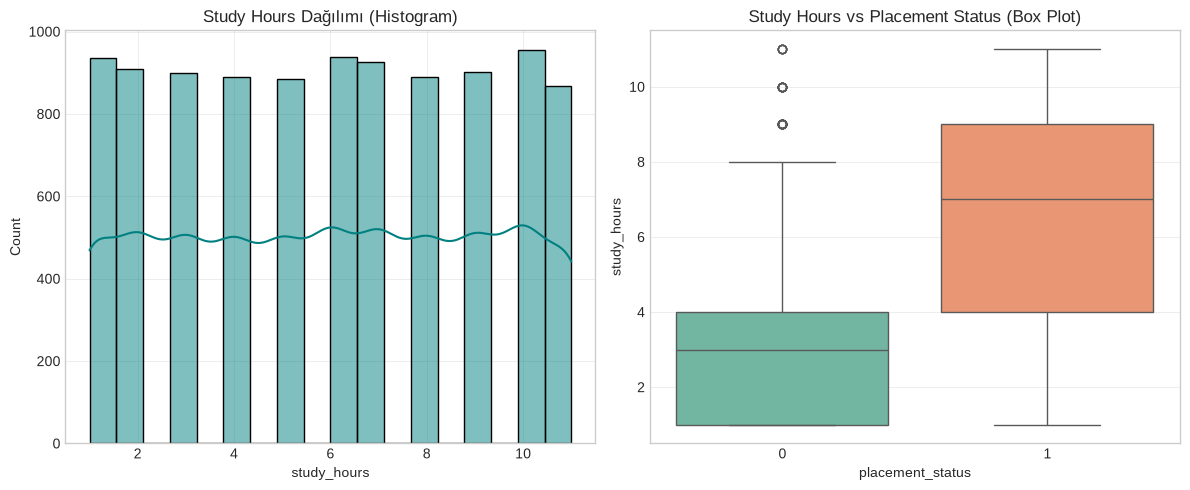

In [6]:
# --- 5. Visualization ---
print("\n6. Görselleştirme: Dağılım ve Aykırı Değer (Outlier) İncelemesi")
plt.figure(figsize=(12, 5))

# Histogram ile dağılım şeklini inceleme
plt.subplot(1, 2, 1)
sns.histplot(df["study_hours"], kde=True, color="teal")
plt.title("Study Hours Dağılımı (Histogram)")

# Box plot ile aykırı değerleri inceleme
plt.subplot(1, 2, 2)
sns.boxplot(x=df["placement_status"], y=df["study_hours"], palette="Set2")
plt.title("Study Hours vs Placement Status (Box Plot)")

plt.tight_layout()
plt.show()

In [7]:
# --- 6. Train Test Split ---
X = df.drop(columns=["placement_status"])
y = df["placement_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n7. Veri Bölündü -> Train: {X_train.shape}, Test: {X_test.shape}")


7. Veri Bölündü -> Train: (8000, 7), Test: (2000, 7)


In [8]:
# --- 7. Feature Extraction ---
def extract_features(data):
    df_feat = data.copy()

    # 1. Sınav Gelişim Farkı
    if "exam_score" in df_feat.columns and "previous_score" in df_feat.columns:
        df_feat["score_diff"] = df_feat["exam_score"] - df_feat["previous_score"]

    # 2. Çalışma Verimliliği
    if "exam_score" in df_feat.columns and "study_hours" in df_feat.columns:
        df_feat["study_efficiency"] = df_feat["exam_score"] / (
            df_feat["study_hours"] + 1
        )

    # 3. Yaşam Dengesi Oranı
    if "sleep_hours" in df_feat.columns and "study_hours" in df_feat.columns:
        df_feat["rest_study_ratio"] = df_feat["sleep_hours"] / (
            df_feat["study_hours"] + 1
        )

    # 4. Toplam Efor İndeksi
    if all(
        col in df_feat.columns
        for col in ["study_hours", "assignments_completed", "attendance"]
    ):
        df_feat["effort_score"] = (
            df_feat["study_hours"]
            + df_feat["assignments_completed"]
            + (df_feat["attendance"] / 10)
        )

    return df_feat

X_train_extracted = extract_features(X_train)
X_test_extracted = extract_features(X_test)
print(f"8. Feature Extraction Sonrası Train Boyutu: {X_train_extracted.shape}")

8. Feature Extraction Sonrası Train Boyutu: (8000, 11)


In [9]:
# --- 8. Correlation Filter (Sadece Eğitim Seti Üzerinde) ---
corr_matrix = X_train_extracted.select_dtypes(
    include=[np.number]
).corr().abs()
corr_threshold = 0.95
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop_corr = [
    col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)
]

X_train_reduced = X_train_extracted.drop(columns=to_drop_corr)
X_test_reduced = X_test_extracted.drop(columns=to_drop_corr, errors="ignore")
print(f"9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: {X_train_reduced.shape[1]}")

9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: 11



10. Feature Selection Tamamlandı. Seçilen En İyi 10 Özellik:
   1. study_hours
   2. attendance
   3. sleep_hours
   4. assignments_completed
   5. previous_score
   6. exam_score
   7. score_diff
   8. study_efficiency
   9. rest_study_ratio
   10. effort_score

Nihai Özellikler Arası Korelasyon Analizi (analysis_utils):
=== Target ile Korelasyon Sıralaması ===
exam_score               0.793911
effort_score             0.474941
score_diff               0.413842
study_hours              0.399905
assignments_completed    0.291757
previous_score           0.230670
attendance               0.170133
sleep_hours              0.116060
study_efficiency        -0.118649
rest_study_ratio        -0.312244
Name: placement_status, dtype: float64
----------------------------------------


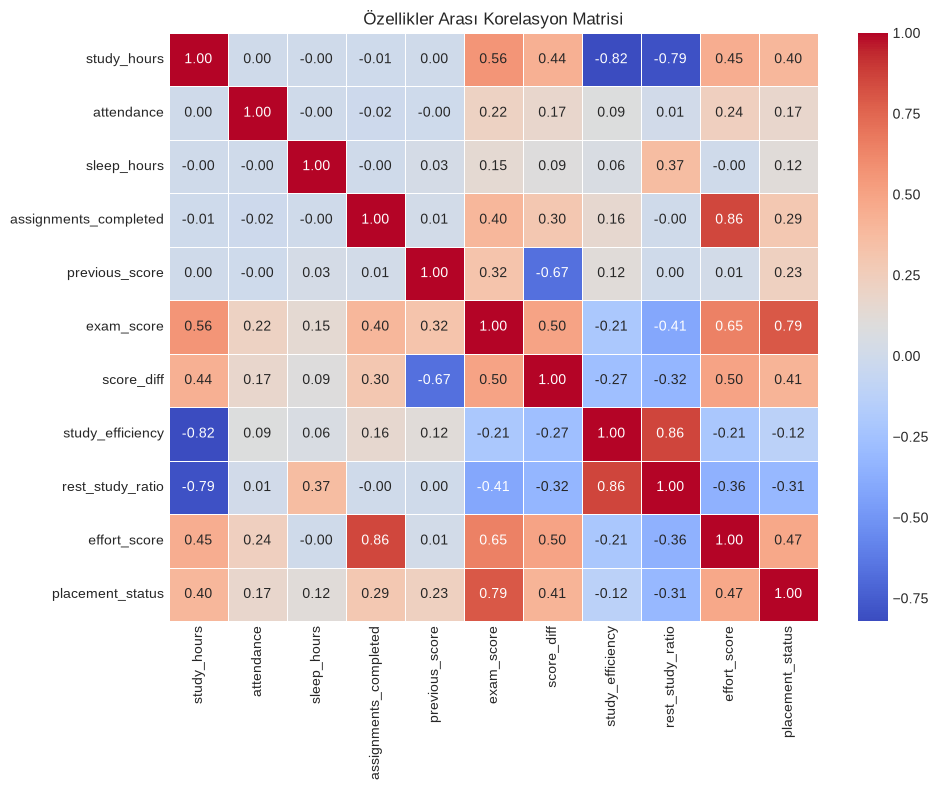

⚠️ Yüksek korelasyonlu (çakışan) özellikler: ['rest_study_ratio', 'effort_score']


In [10]:
# --- 10. Feature Selection (SelectKBest / ANOVA) ---
k_best_count = 10
selector = SelectKBest(score_func=f_classif, k=k_best_count)

X_train_selected_array = selector.fit_transform(X_train_reduced, y_train)
selected_mask = selector.get_support()
final_features = X_train_reduced.columns[selected_mask]

# Nihai Havuzlar
X_train_final = X_train_reduced[final_features]
X_test_final = X_test_reduced[final_features]

print(f"\n10. Feature Selection Tamamlandı. Seçilen En İyi {k_best_count} Özellik:")
for i, feat in enumerate(final_features, 1):
    print(f"   {i}. {feat}")

# Nihai veri çerçevesi üzerinden analysis_utils fonksiyonu ile temiz korelasyon görselleştirmesi
df_train_final = pd.concat([X_train_final, y_train], axis=1)
print("\nNihai Özellikler Arası Korelasyon Analizi (analysis_utils):")
target_corr, to_drop = analyze_feature_correlations(
    df_train_final, target_col="placement_status", corr_threshold=0.85
)